In [1]:
!pip install pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [3]:
from google.colab import files

uploaded = files.upload()

Saving hdfc_loan_dataset_full_enriched.csv to hdfc_loan_dataset_full_enriched.csv


In [4]:
df = pd.read_csv("hdfc_loan_dataset_full_enriched.csv")

df.head()

,Loan_ID,Bank,Customer_Name,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term_Months,Credit_History,Property_Area,Age,Loan_Status,CIBIL_Score,Annual_Household_Income,Debt_to_Income_Ratio,Purpose_of_Loan,Existing_EMIs,Number_of_Previous_Loans,Default_History_Count,Employment_Length_Years,Business_Type,Asset_Value,Guarantor,Co-signer_Relationship,Monthly_Expense,Organization_Type,Region_Branch,Mobile_Verified,Email_Verified,Institutional_Relationships,Application_Text,Customer_Feedback,Agent_Notes,Loan_to_Annual_Income,Customer_Sentiment,Religion,State,City,PIN_Code,Aadhaar_Synthetic,Phone_Number,Email,Occupation
0,HDFC100001,HDFC Bank,Rohan Verma,Male,No,2,Graduate,Salaried,56976,0,8031545,360,1,Urban,36,Approved,699,683712,0.098,Home,5610,0,0,1,NaN,744861,No,Friend,30391,Public,KOL-004,No,Yes,"RBI:Regulatory, NPCI:Payments integration, CIB...",Applicant requests home loan for amount INR 80...,Neutral — application was okay; expects quicke...,Verified documents; requires guarantor for app...,11.747,Positive,Hindu,Delhi,Dwarka,857743,6.940000e+11,9068671773,rohan.verma@example.in,Farmer
1,HDFC100002,HDFC Bank,Rohan Verma,Male,No,0,Graduate,Unemployed,1856,0,899361,240,1,Rural,42,Rejected,707,22272,4.939,Business,9166,1,0,0,NaN,0,No,Sibling,1856,Startup,DEL-001,No,Yes,"NPCI:UPI integrations, SWIFT:International tra...",Applicant requests business loan for amount IN...,Complained about credit score errors and wants...,Escalated to relationship manager for manual C...,40.381,Negative,Hindu,Punjab,Ludhiana,863836,6.330000e+11,9990772625,rohan.verma@example.in,Civil Engineer
2,HDFC100003,HDFC Bank,Aditya Nair,Female,Yes,0,Graduate,Salaried,64553,0,2387748,60,1,Rural,38,Approved,641,774636,0.000,Business,0,2,0,1,NaN,2913766,No,NaN,24557,Private,BLR-003,Yes,Yes,"CIBIL:Credit checks, NPCI:Payments, GSTN:Tax l...",Applicant requests business loan for amount IN...,"Satisfied with application process, but unhapp...",Escalated to relationship manager for manual C...,3.082,Positive,Hindu,Maharashtra,Nagpur,834796,1.660000e+11,9195085016,aditya.nair@example.in,Medical Representative
3,HDFC100004,HDFC Bank,Ananya Joshi,Male,No,0,Graduate,Salaried,88450,0,658856,12,1,Semiurban,32,Approved,677,1061400,0.301,Personal,26613,1,0,3,NaN,3488244,No,Friend,36750,Startup,KOL-004,Yes,Yes,"NPCI:UPI integrations, SWIFT:International tra...",Applicant mentions dispute with property valua...,Complained about credit score errors and wants...,Escalated to relationship manager for manual C...,0.621,Negative,Hindu,Gujarat,Vadodara,438590,5.528183e+10,9179335548,ananya.joshi@example.in,Marketing Executive
4,HDFC100005,HDFC Bank,Harpreet Singh,Male,Yes,3,Graduate,Self-Employed,9539,0,198671,36,0,Semiurban,35,Approved,594,114468,0.000,Personal,0,0,0,2,Agriculture,472179,No,Parent,3920,Public,BLR-003,Yes,Yes,"NPCI:UPI integrations, SWIFT:International tra...",Applicant mentions dispute with property valua...,Appreciative of online service and prompt comm...,Verified documents; requires guarantor for app...,1.736,Neutral,Sikh,West Bengal,Kolkata,495224,1.560000e+11,9795137116,harpreet.singh@example.in,Shopkeeper


In [7]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (1000, 47)

Columns:
['Loan_ID', 'Bank', 'Customer_Name', 'Gender', 'Married', 'Dependents', 'Education', 'Employment_Status', 'Applicant_Income', 'Coapplicant_Income', 'Loan_Amount', 'Loan_Term_Months', 'Credit_History', 'Property_Area', 'Age', 'Loan_Status', 'CIBIL_Score', 'Annual_Household_Income', 'Debt_to_Income_Ratio', 'Purpose_of_Loan', 'Existing_EMIs', 'Number_of_Previous_Loans', 'Default_History_Count', 'Employment_Length_Years', 'Business_Type', 'Asset_Value', 'Guarantor', 'Co-signer_Relationship', 'Monthly_Expense', 'Organization_Type', 'Region_Branch', 'Mobile_Verified', 'Email_Verified', 'Institutional_Relationships', 'Application_Text', 'Customer_Feedback', 'Agent_Notes', 'Loan_to_Annual_Income', 'Customer_Sentiment', 'Religion', 'State', 'City', 'PIN_Code', 'Aadhaar_Synthetic', 'Phone_Number', 'Email', 'Occupation']


In [8]:
import os

os.makedirs("visuals/usecase1", exist_ok=True)
os.makedirs("visuals/usecase2", exist_ok=True)
os.makedirs("visuals/usecase3", exist_ok=True)

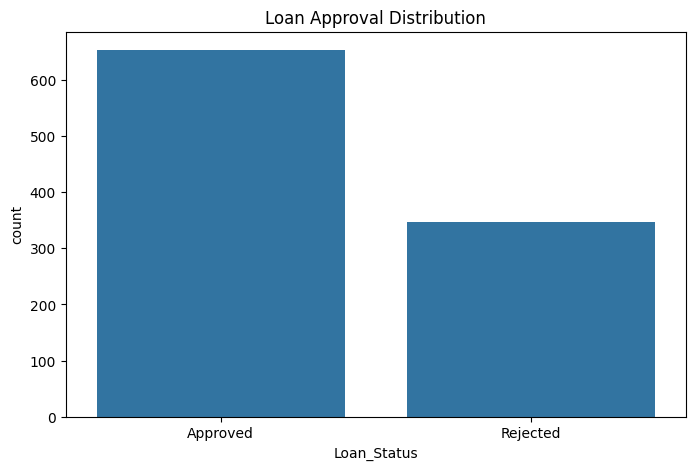

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Loan_Status"
)

plt.title("Loan Approval Distribution")

plt.savefig(
    "visuals/usecase1/loan_status_distribution.png",
    bbox_inches="tight"
)

plt.show()

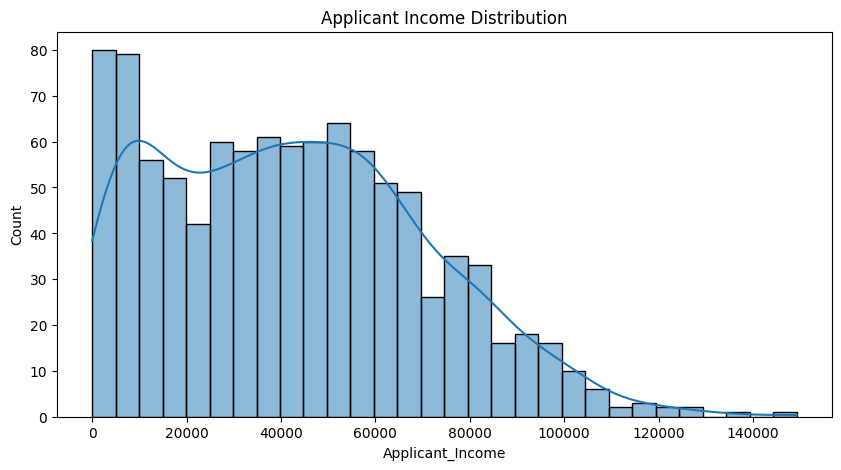

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Applicant_Income"],
    bins=30,
    kde=True
)

plt.title("Applicant Income Distribution")

plt.savefig(
    "visuals/usecase1/applicant_income_distribution.png",
    bbox_inches="tight"
)

plt.show()

In [11]:
numeric_df = df.select_dtypes(include=np.number)

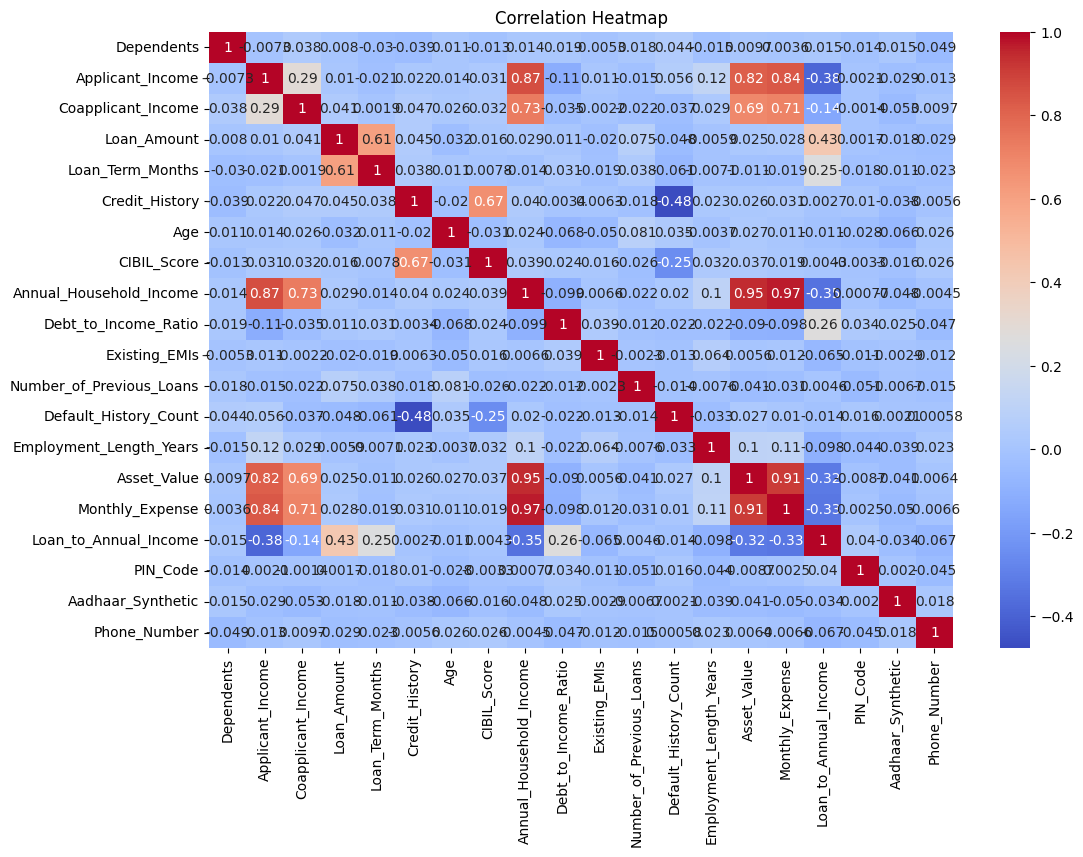

In [12]:
plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "visuals/usecase1/correlation_heatmap.png",
    bbox_inches="tight"
)

plt.show()

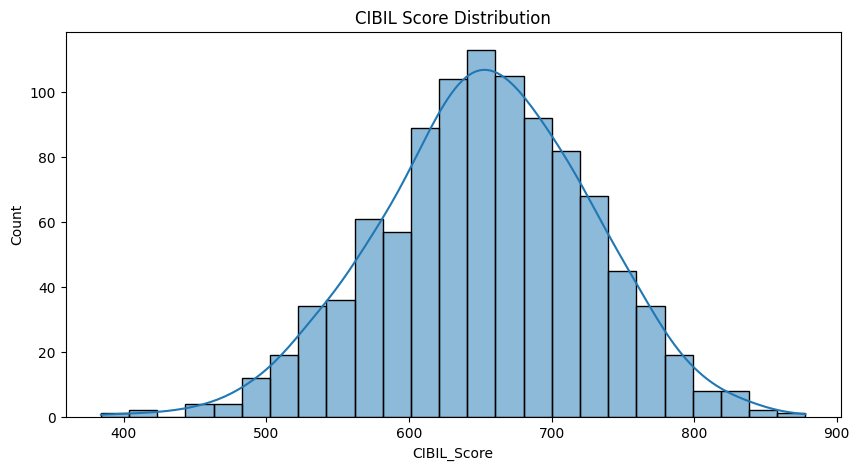

In [13]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["CIBIL_Score"],
    bins=25,
    kde=True
)

plt.title("CIBIL Score Distribution")

plt.savefig(
    "visuals/usecase1/cibil_score_distribution.png",
    bbox_inches="tight"
)

plt.show()

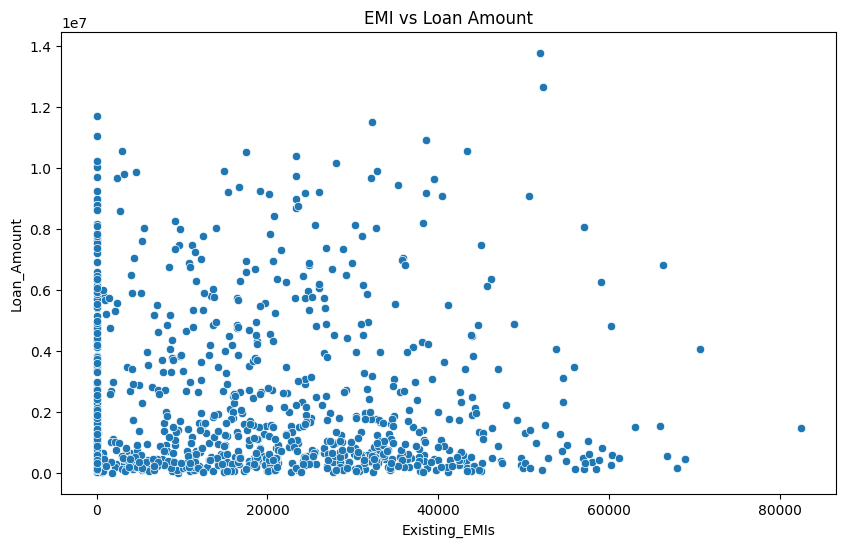

In [14]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Existing_EMIs",
    y="Loan_Amount"
)

plt.title("EMI vs Loan Amount")

plt.savefig(
    "visuals/usecase1/emi_vs_loan_amount.png",
    bbox_inches="tight"
)

plt.show()

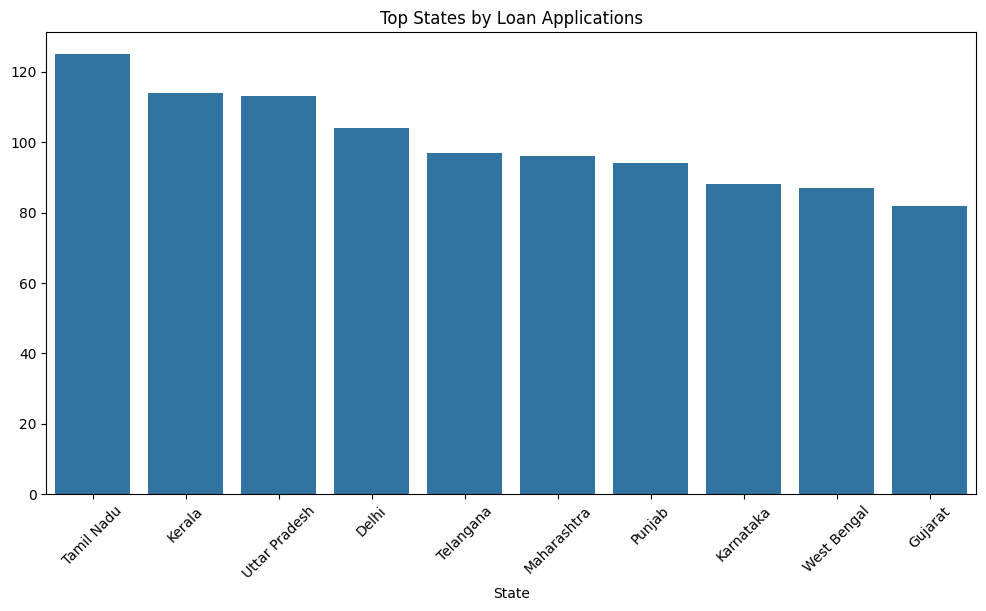

In [15]:
top_states = (
    df["State"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_states.index,
    y=top_states.values
)

plt.xticks(rotation=45)

plt.title("Top States by Loan Applications")

plt.savefig(
    "visuals/usecase1/state_wise_loans.png",
    bbox_inches="tight"
)

plt.show()